# **SENTIMENT ANALYSIS**

## Table of Contents
1. [Introduction](#introduction)
2. [RoBERTa](#roberta)
3. [Zero-shot Classification](#zero-shot-classification)
4. [References](#references)

## Introduction

## RoBERTa

In this section, we perform sentiment analysis on subtitle scripts from Disney and Ghibli films. We use a RoBERTa-based sentiment classifier to evaluate emotional tone over the course of each movie and compare the overall sentiment distributions between the two studios.

 Note: We tested other models like "tabularisai/multilingual-sentiment-analysis" and "sarahai/movie-sentiment-analysis" but found their outputs inaccurate and poorly calibrated for our domain.

**Step 1: Perform sentiment classification on Disney and Ghibli**

In this step, we apply a sentence-level sentiment analysis to all cleaned and segmented subtitle lines using the CardiffNLP's twitter-roberta-base-sentiment model from Hugging Face. This model is a fine-tuned RoBERTa transformer designed for classifying short texts into three sentiment categories: positive, neutral, and negative.

We use a reusable function that:
- Loads all lines from a text file.
- Applies the RoBERTa model to predict the sentiment of each line.
- Records the predicted label and confidence score.
- Saves the full output in a structured CSV file.

We run this function separately for both Disney and Ghibli sentence datasets, resulting in 'subtitles_sentiment_roberta_disney.csv' and 'subtitles_sentiment_roberta_ghibli.csv', stored in the Sentiment_Analysis folder, in 'RoBERTa'.

In [3]:
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import pandas as pd
from tqdm import tqdm
import os

# load model
model_name = "cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)
model.eval()
labels = ['negative', 'neutral', 'positive']

def analyze_sentiment(input_txt_path, output_csv_path):
    """
    Perform sentiment analysis on all lines of a given file and save results as CSV file.
    """
    with open(input_txt_path, "r", encoding="utf-8") as f:
        lines = [line.strip() for line in f if line.strip()]

    results = []

    for line in tqdm(lines, desc=f"Analyzing {os.path.basename(input_txt_path)}"):
        encoded = tokenizer(line, truncation=True, max_length=514, return_tensors="pt")
        with torch.no_grad():
            output = model(**encoded)
            probs = F.softmax(output.logits, dim=1)
            pred = torch.argmax(probs, dim=1).item()
            score = probs[0][pred].item()

        results.append({
            "text": line,
            "sentiment": labels[pred],
            "score": round(score, 4)
        })

    df = pd.DataFrame(results)
    df.to_csv(output_csv_path, index=False)
    print(f"Saved sentiment results to {output_csv_path}")
    return df


In [2]:
analyze_sentiment(
    input_txt_path="data/data_in_sentences/ghibli_sentences.txt",
    output_csv_path="Sentiment_Analysis/RoBERTa/sentiment_roberta_ghibli.csv"
)

analyze_sentiment(
    input_txt_path="data/data_in_sentences/disney_sentences.txt",
    output_csv_path="Sentiment_Analysis/RoBERTa/sentiment_roberta_disney.csv"
)


Analyzing ghibli_sentences.txt: 100%|██████████| 19276/19276 [23:22<00:00, 13.74it/s] 


Saved sentiment results to Sentiment_Analysis/RoBERTa/sentiment_roberta_ghibli.csv


Analyzing disney_sentences.txt: 100%|██████████| 27159/27159 [33:39<00:00, 13.45it/s]  


Saved sentiment results to Sentiment_Analysis/RoBERTa/sentiment_roberta_disney.csv


,text,sentiment,score
0,I know you I walked with you once upon a dream...,positive,0.5815
1,"Many years had they longed for a child, and fi...",positive,0.6673
2,"A daughter was born, and they called her Aurora.",neutral,0.8539
3,"Sweet Aurora Yes, they named her after the daw...",positive,0.9195
4,Then a great holiday was proclaimed throughout...,positive,0.7966
...,...,...,...
27154,"Well, you're welcome to stay.",positive,0.8422
27155,"There's not really any more surprises, but, yo...",neutral,0.6387
27156,Good luck getting that song out of your head.,neutral,0.5302
27157,It's a real earwig.,neutral,0.7414


**Step 2: Comparing Sentiment Distribution Across Studios**

In this step, we load the .csv files containing sentence-level sentiment labels for Disney and Ghibli films.

We use value_counts(normalize=True) to compute the proportional distribution of sentiments for each studio. This allows us to see, for example, whether Ghibli movies tend to be more neutral or if Disney has a higher proportion of positive lines.

A bar chart is generated to visualize the sentiment breakdown for the two studios.

<Figure size 800x500 with 0 Axes>

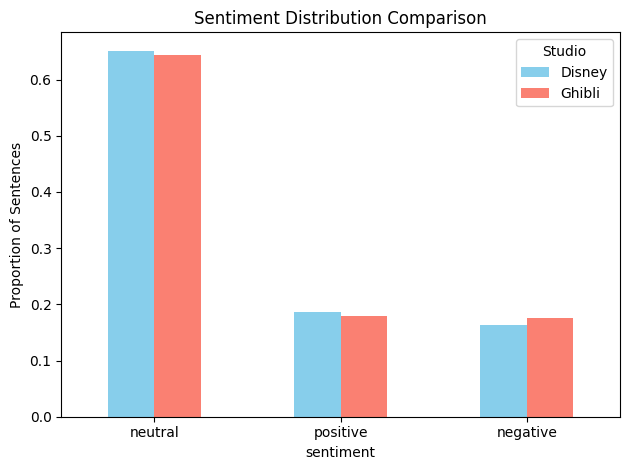

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# load sentiment data
disney_df = pd.read_csv("Sentiment_Analysis/RoBERTa/sentiment_roberta_disney.csv")
ghibli_df = pd.read_csv("Sentiment_Analysis/RoBERTa/sentiment_roberta_ghibli.csv")

# calculate sentiment distribution
disney_counts = disney_df['sentiment'].value_counts(normalize=True)
ghibli_counts = ghibli_df['sentiment'].value_counts(normalize=True)

# combine into comparison DataFrame
comparison_df = pd.DataFrame({
    'Disney': disney_counts,
    'Ghibli': ghibli_counts
}).fillna(0)

# plot sentiment distributions
plt.figure(figsize=(8, 5))
comparison_df.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Sentiment Distribution Comparison")
plt.ylabel("Proportion of Sentences")
plt.xticks(rotation=0)
plt.legend(title="Studio")
plt.tight_layout()

# save chart
plt.savefig("Sentiment_Analysis/RoBERTa/sentiment_roberta_comparison_disney_vs_ghibli.png", dpi=300)
plt.show()


**Step 3: Sentiment Progression for Every Film**

In this step, we initialize a single instance of the RoBERTa-based sentiment classifier (along with its tokenizer) and then apply it uniformly across every subtitle sentences file. We define a helper function, analyze_sentiment, which reads every non-empty line from a given subtitle file, encodes it for RoBERTa, obtains the model’s probability distribution over “negative,” “neutral,” and “positive” classes, and records both the predicted label and its confidence score. These per-line results are collected into a pandas DataFrame and written out as a CSV. A second helper, analyze_all_movies, simply automates this process over every .txt file in a folder. Finally, we run this pipeline twice, once for Disney and once for Ghibli, producing a neatly organized set of sentiment‐progression CSVs (one per film).

In [ ]:
# load model and tokenizer
model_name = "cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)
model.eval()
labels = ['negative', 'neutral', 'positive']

# single file analyzer
def analyze_sentiment(input_txt_path, output_csv_path):
    """
    Run sentiment classification on all lines in a file and save results to CSV.
    """
    with open(input_txt_path, "r", encoding="utf-8") as f:
        lines = [line.strip() for line in f if line.strip()]

    results = []

    for line in tqdm(lines, desc=f"Analyzing {os.path.basename(input_txt_path)}"):
        encoded = tokenizer(line, truncation=True, max_length=514, return_tensors="pt")
        with torch.no_grad():
            output = model(**encoded)
            probs = F.softmax(output.logits, dim=1)
            pred = torch.argmax(probs, dim=1).item()
            score = probs[0][pred].item()

        results.append({
            "text": line,
            "sentiment": labels[pred],
            "score": round(score, 4)
        })

    df = pd.DataFrame(results)
    df.to_csv(output_csv_path, index=False)
    print(f"Saved: {output_csv_path}")

# for all files in folder
def analyze_all_movies(input_folder, output_folder):
    """
    Run sentiment analysis on all subtitle sentence files in a folder.
    """
    os.makedirs(output_folder, exist_ok=True)

    for filename in os.listdir(input_folder):
        if filename.endswith("_sentences.txt"):
            input_path = os.path.join(input_folder, filename)
            base_name = filename.replace("_sentences.txt", "")
            output_path = os.path.join(output_folder, f"{base_name}_sentiment.csv")

            analyze_sentiment(input_path, output_path)


# run for Disney and Ghibli
analyze_all_movies("data/data_in_sentences/disney", "Sentiment_Analysis/RoBERTa/sentiment_progression/disney")
analyze_all_movies("data/data_in_sentences/ghibli", "Sentiment_Analysis/RoBERTa/sentiment_progression/ghibli")



Analyzing Moana_cleaned_sentences.txt: 100%|██████████| 1050/1050 [01:16<00:00, 13.77it/s]


Saved: Sentiment_Analysis/RoBERTa/sentiment_progression/disney/Moana_cleaned_sentiment.csv


Analyzing Brave_cleaned_sentences.txt: 100%|██████████| 1195/1195 [01:22<00:00, 14.42it/s]


Saved: Sentiment_Analysis/RoBERTa/sentiment_progression/disney/Brave_cleaned_sentiment.csv


Analyzing Snow.White.and.the.Seven.Dwarfs_cleaned_sentences.txt: 100%|██████████| 754/754 [00:54<00:00, 13.93it/s]


...

Saved: Sentiment_Analysis/RoBERTa/sentiment_progression/ghibli/Porco.Rosso_cleaned_sentiment.csv


Analyzing The.Secret.World.of.Arrietty_cleaned_sentences.txt: 100%|██████████| 655/655 [00:46<00:00, 13.97it/s]


Saved: Sentiment_Analysis/RoBERTa/sentiment_progression/ghibli/The.Secret.World.of.Arrietty_cleaned_sentiment.csv


Analyzing Only.Yesterday_cleaned_sentences.txt: 100%|██████████| 1399/1399 [01:39<00:00, 14.03it/s]

Saved: Sentiment_Analysis/RoBERTa/sentiment_progression/ghibli/Only.Yesterday_cleaned_sentiment.csv


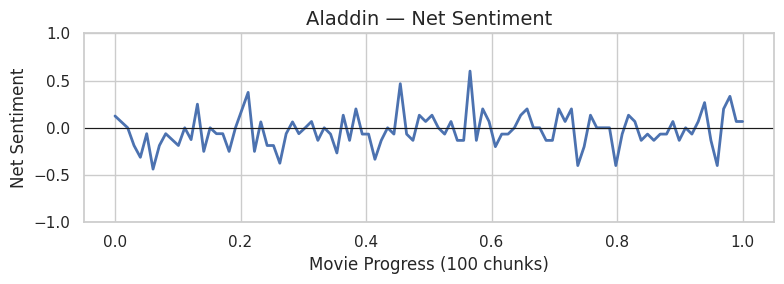

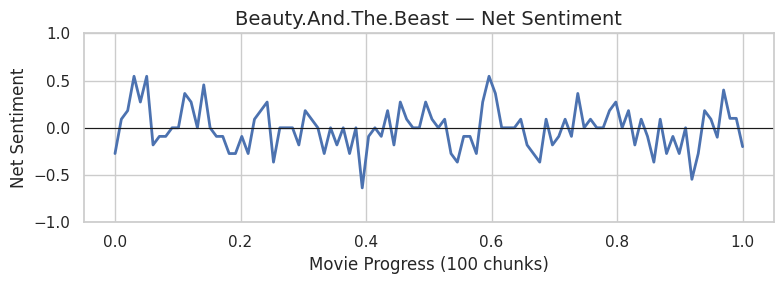

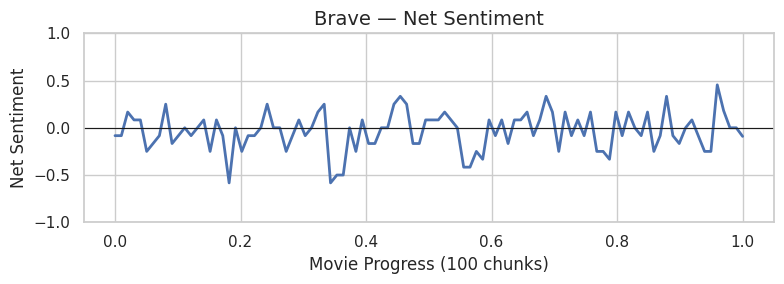

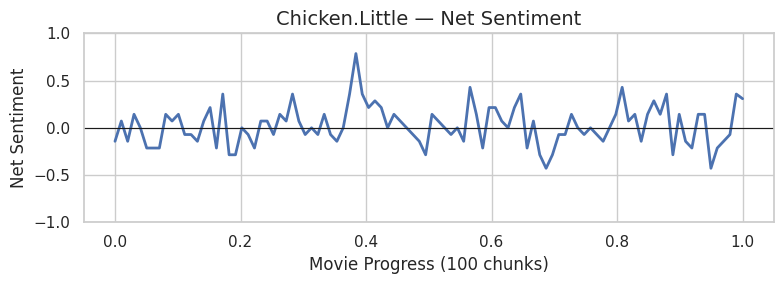

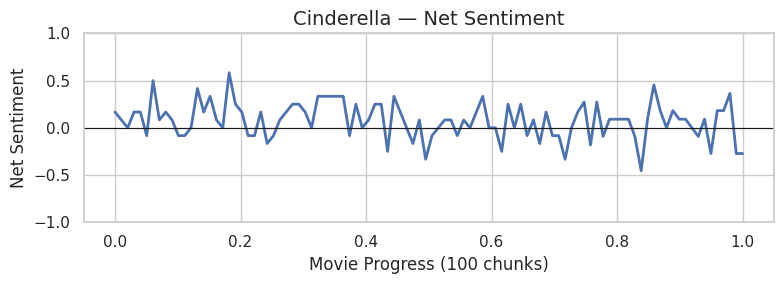

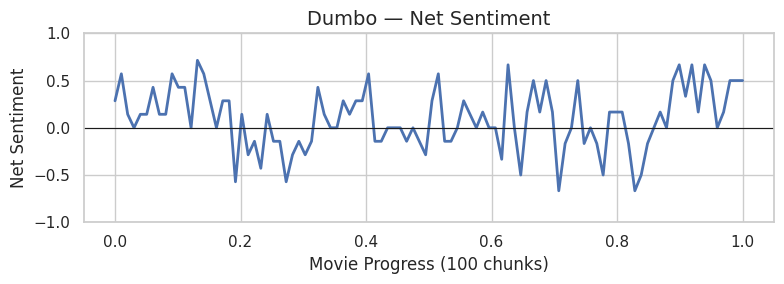

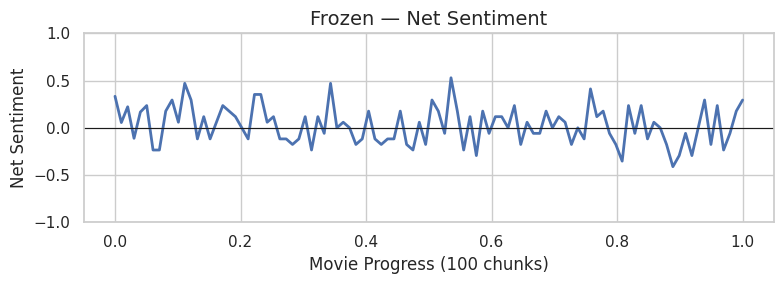

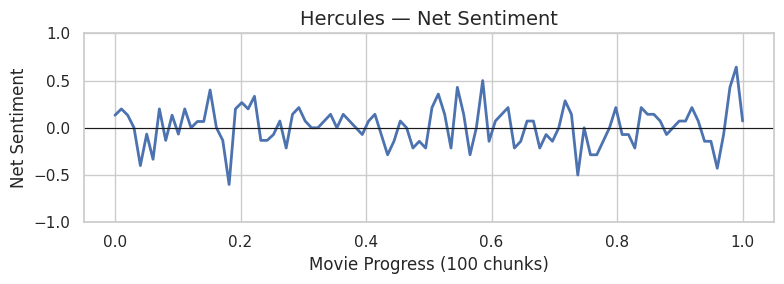

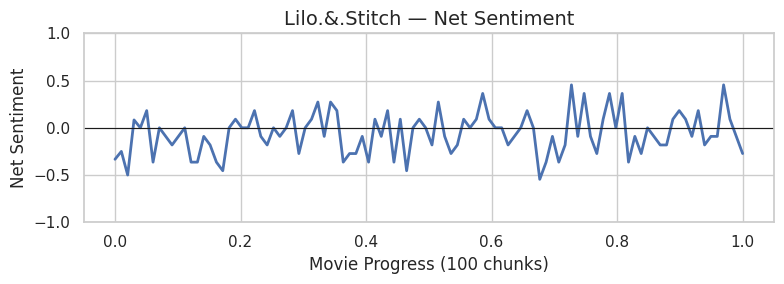

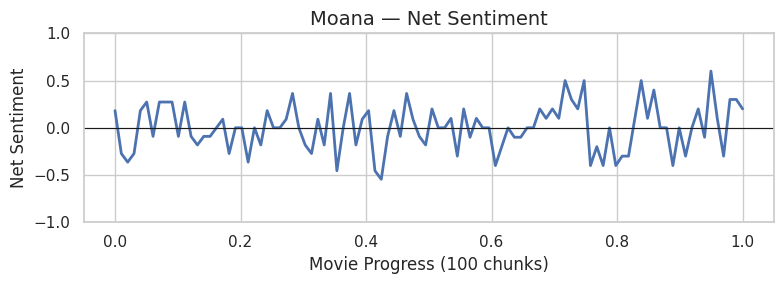

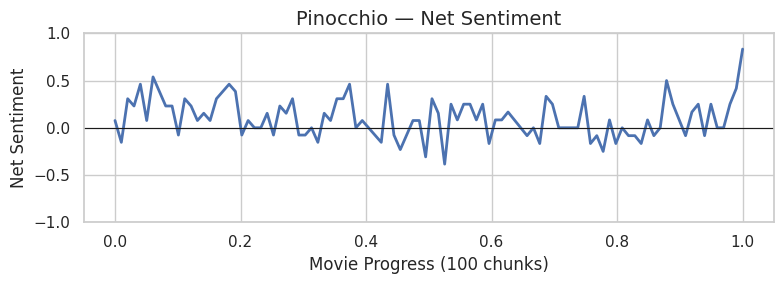

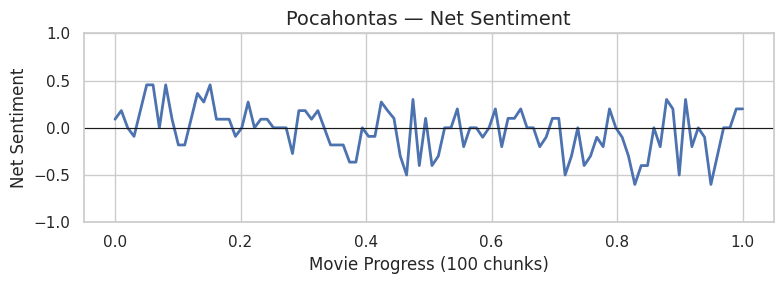

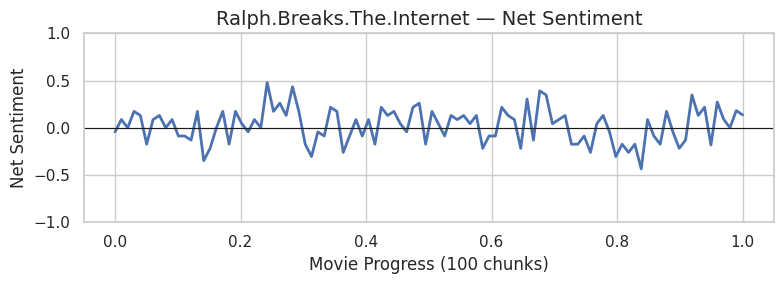

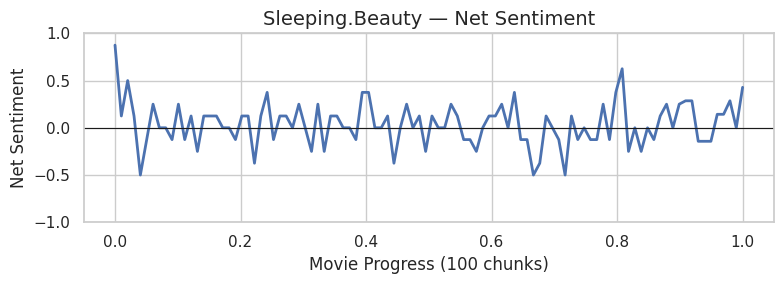

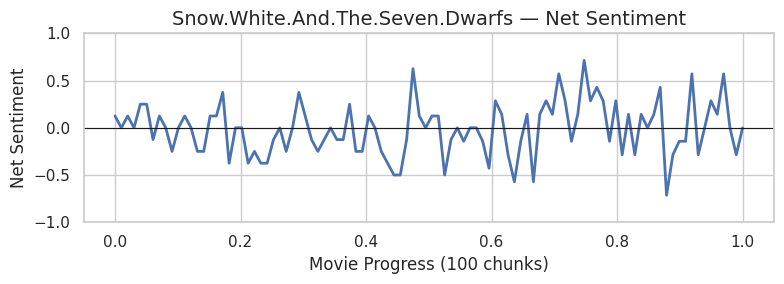

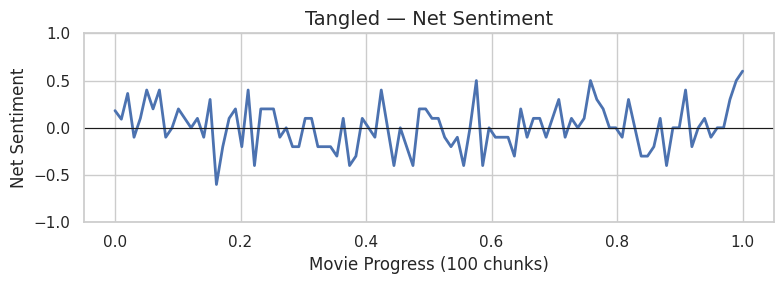

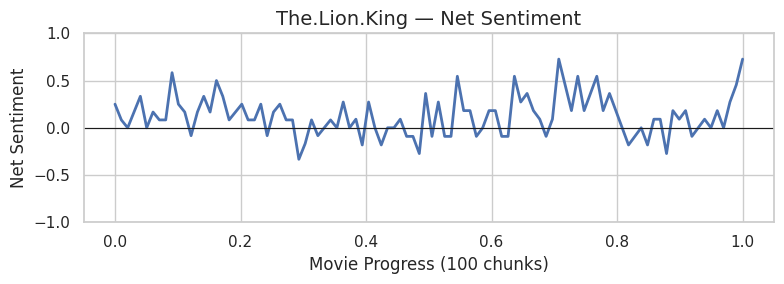

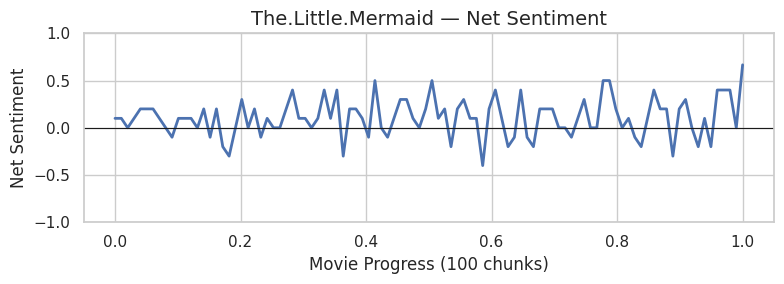

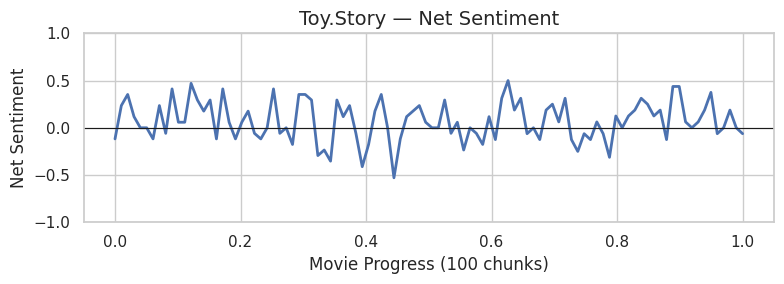

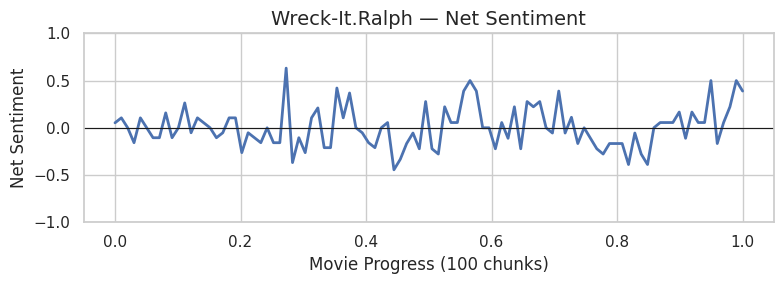

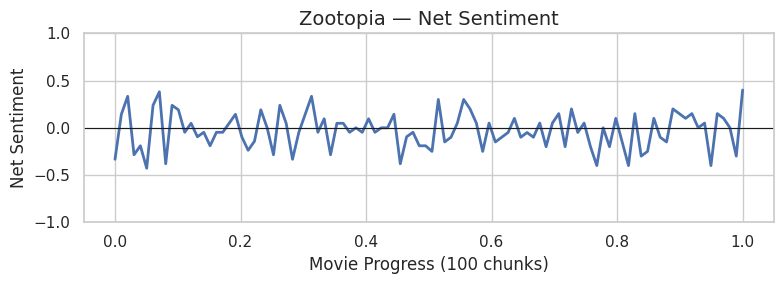

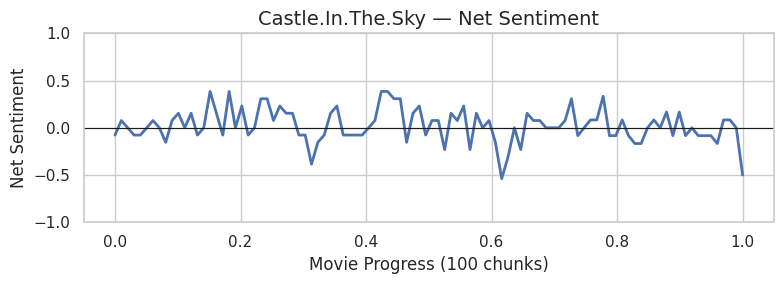

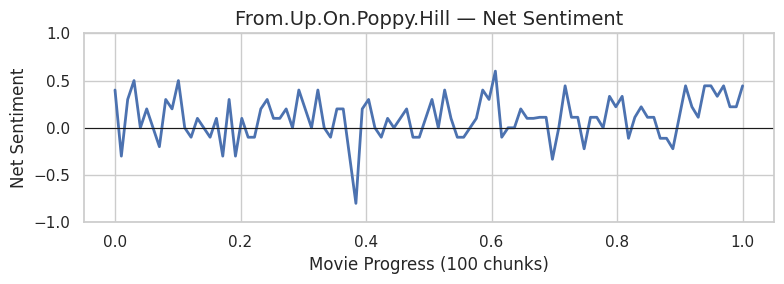

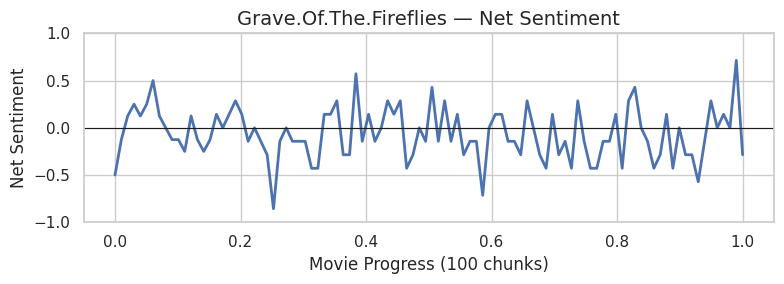

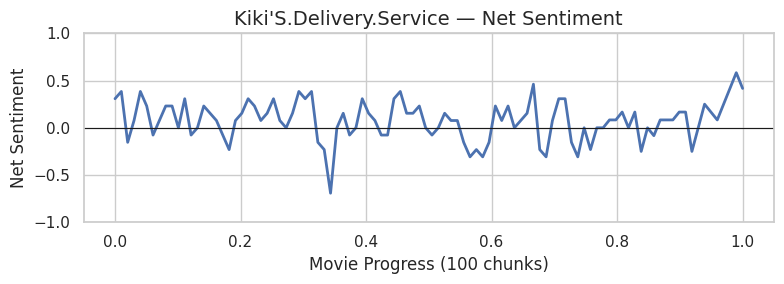

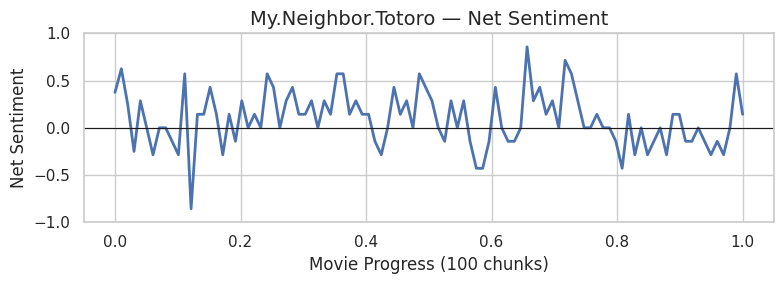

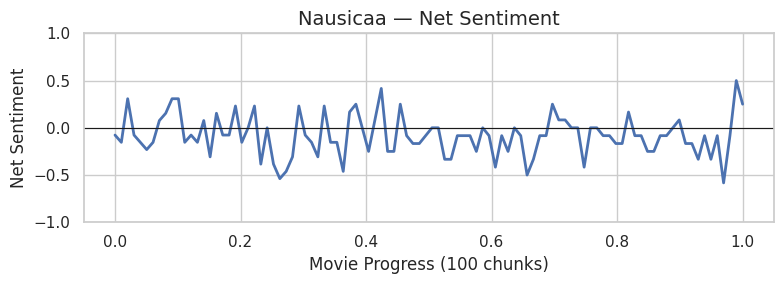

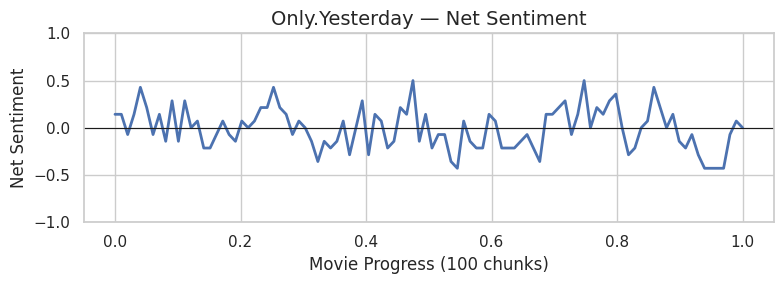

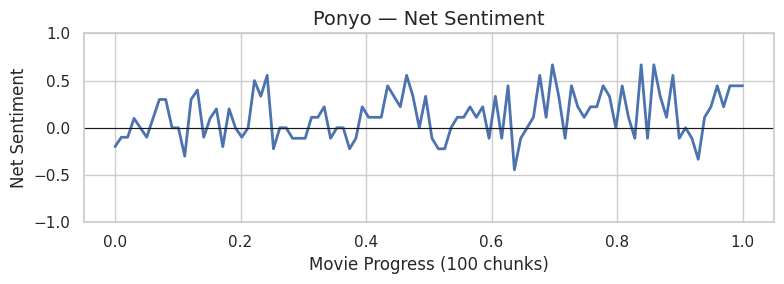

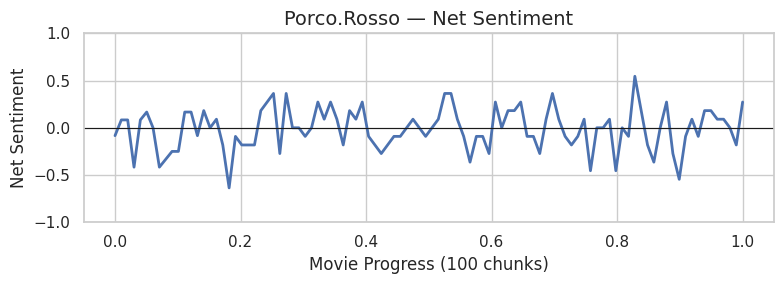

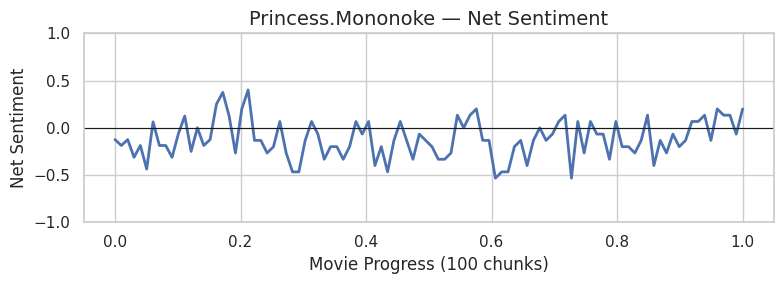

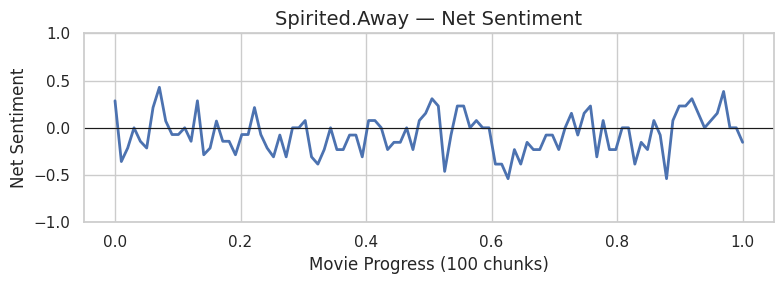

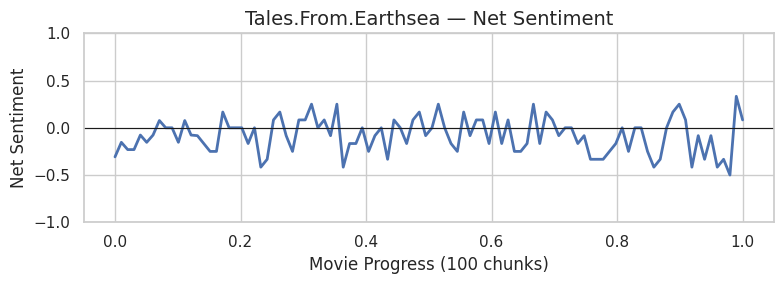

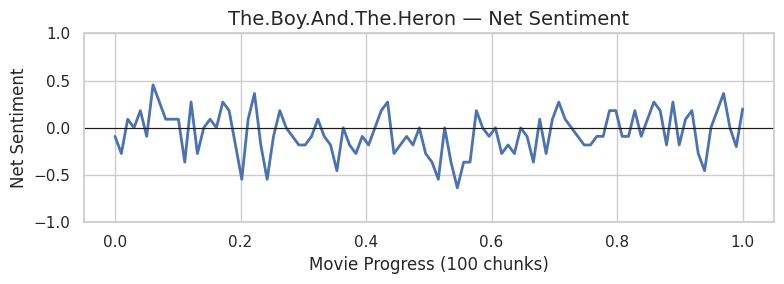

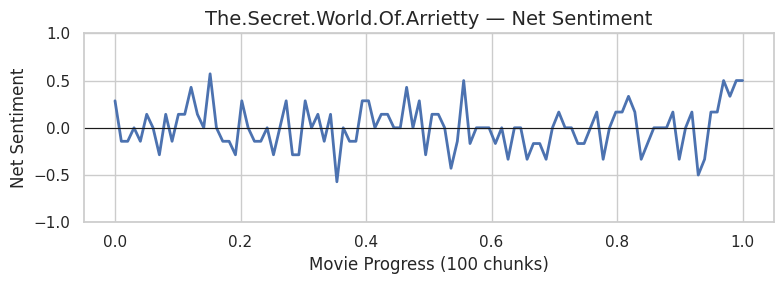

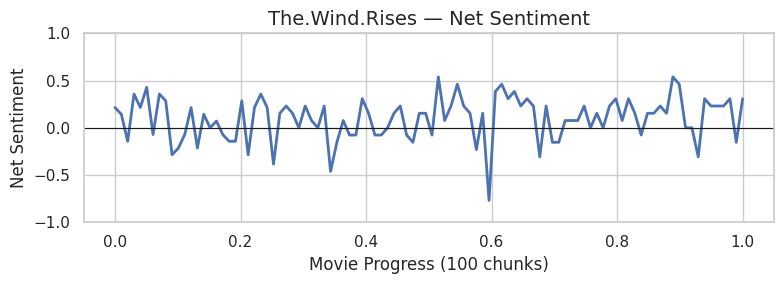

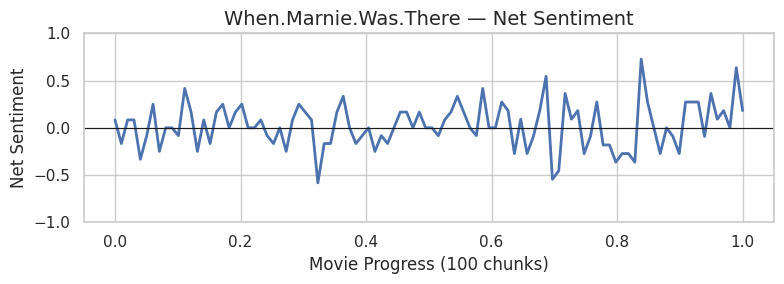

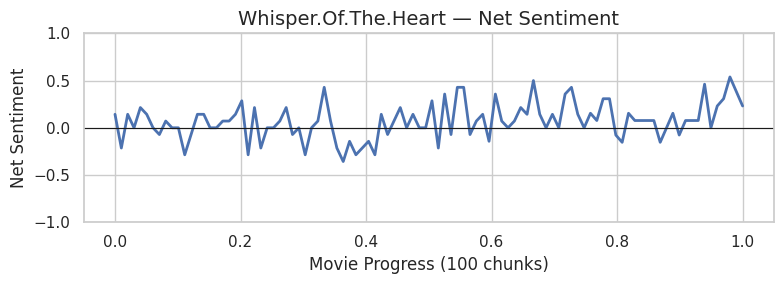

In [ ]:
import os, glob, numpy as np

def plot_net_sentiment(csv_paths, output_dir="sentiment_plots"):
    """
    For each sentiment CSV in `csv_paths`, compute the net sentiment over 
    100 equal-sized chunks, plot it, show it, and save the figure to `output_dir`.
    """
    os.makedirs(output_dir, exist_ok=True)
    
    for path in csv_paths:
        fname = os.path.basename(path)
        base  = fname.replace("_sentiment.csv", "").replace("_cleaned", "")
        film  = base.replace("_", " ").title()
        
        df = pd.read_csv(path)
        sents = df["sentiment"].values
        
        # chunk into 100 segments and compute net sentiment (pos – neg)
        chunks   = np.array_split(sents, 100)
        pos_frac = np.array([np.mean(c == "positive") for c in chunks])
        neg_frac = np.array([np.mean(c == "negative") for c in chunks])
        net      = pos_frac - neg_frac
        
        # plot
        x = np.linspace(0, 1, len(net))
        plt.figure(figsize=(8,3))
        plt.plot(x, net, color="C0", lw=2)
        plt.axhline(0, color="k", lw=0.8)
        plt.title(f"{film} — Net Sentiment", fontsize=14)
        plt.xlabel("Movie Progress (100 chunks)")
        plt.ylabel("Net Sentiment")
        plt.ylim(-1, 1)
        plt.tight_layout()
        
        # save figure
        outpath = os.path.join(output_dir, f"{base}_net_sentiment.png")
        plt.savefig(outpath)
        plt.show()

disney = sorted(glob.glob("Sentiment_Analysis/RoBERTa/sentiment_progression/disney/*_sentiment.csv"))
ghibli = sorted(glob.glob("Sentiment_Analysis/RoBERTa/sentiment_progression/ghibli/*_sentiment.csv"))

# Run plotting + saving
plot_net_sentiment(disney + ghibli, output_dir="Sentiment_Analysis/RoBERTa/sentiment_progression/sentiment_plots")

## Zero-shot Classification

Aquí explicar